# Week 12 Homework: ARIA v8.0 — The Classification Engine

本週你要將 ARIA 系統從 v7.0 升級到 **v8.0 — The Classification Engine**。v7.0 用的是 pixel-level 的閾值（NDVI > T、VV < T_dB）；v8.0 引入分類器，從「一次一個指標分兩類」升級到「同時用所有波段分多類」。

**升級邏輯：**
```
v5.0 (W8)  → 光譜判讀：哪裡有異常？（目視 + 假彩色）
v6.0 (W9)  → 變遷偵測：變了多少？可信嗎？（ΔNDVI + confusion matrix）
v7.0 (W10) → SAR 融合：雲下面發生了什麼？（多源閾值 + 確信度）
v8.0 (W12) → 影像分類：每個像素是什麼地物？（K-means + Random Forest）⬆
```

**Key Deliverable:** A Colab/Jupyter notebook (.ipynb) that demonstrates:
- STAC API 串流 Sentinel-2 多光譜影像（延續 W8–W10 工作流）
- K-means 非監督式分類 → 地物分群
- Random Forest 監督式分類 → 地物類別圖
- Confusion matrix 分類精度評估（呼應 W9）
- AI-generated classification report

---

## Scenario（任務情境）

指揮官不再滿足於「哪裡有異常」。他需要一張完整的**災後土地覆蓋圖**——每個像素對應一個類別：水體、森林、農田、裸地/崩塌、建物/都市。這張圖是所有後續分析（避難所評估、路網可達性、崩塌面積計算）的基礎圖資。

Your task: using post-earthquake Sentinel-2 imagery, build a multi-class land cover classification for the **Xiulin / Taroko area**（秀林 / 太魯閣）— a study area different from the in-class Demo — and evaluate classification quality.

### STAC API 搜尋影像

Study area BBOX:
[121.4, 24.1, 121.8, 24.25]

Classification bands:
['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

All bands to load:
['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'SCL']

Searching late April, CC < 50%...
  → Found 1 scenes

Searching May, CC < 50%...
  → Found 0 scenes

Searching June, CC < 50%...
  → Found 1 scenes

Searching July, CC < 50%...
  → Found 5 scenes

Searching August, CC < 50%...
  → Found 4 scenes

Searching September, CC < 50%...
  → Found 3 scenes

Searching October, CC < 50%...
  → Found 2 scenes

Searching November, CC < 50%...
  → Found 2 scenes

Searching December, CC < 50%...
  → Found 1 scenes

Top 3 candidate Sentinel-2 scenes:


,Candidate,Item_ID,Date,STAC_Cloud_Cover_percent
0,0,S2A_MSIL2A_20240827T022531_R046_T51QUG_2024082...,2024-08-27,8.36
1,1,S2B_MSIL2A_20240901T022539_R046_T51QUG_2024090...,2024-09-01,11.67
2,2,S2A_MSIL2A_20240718T022551_R046_T51QUG_2024071...,2024-07-18,12.43



Loading Candidate 0
Item ID: S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
Date: 2024-08-27 02:25:31.024000+00:00
STAC cloud cover: 8.36%
Image size: 852 x 2041
SCL cloud / invalid ratio: 0.083
Valid feature matrix: (1593880, 6)

Loading Candidate 1
Item ID: S2B_MSIL2A_20240901T022539_R046_T51QUG_20240901T044409
Date: 2024-09-01 02:25:39.024000+00:00
STAC cloud cover: 11.67%
Image size: 852 x 2041
SCL cloud / invalid ratio: 0.174
Valid feature matrix: (1436210, 6)

Loading Candidate 2
Item ID: S2A_MSIL2A_20240718T022551_R046_T51QUG_20240718T074845
Date: 2024-07-18 02:25:51.024000+00:00
STAC cloud cover: 12.43%
Image size: 852 x 2041
SCL cloud / invalid ratio: 0.019
Valid feature matrix: (1705194, 6)


c:\Users\88695\anaconda3\Lib\site-packages\matplotlib\cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


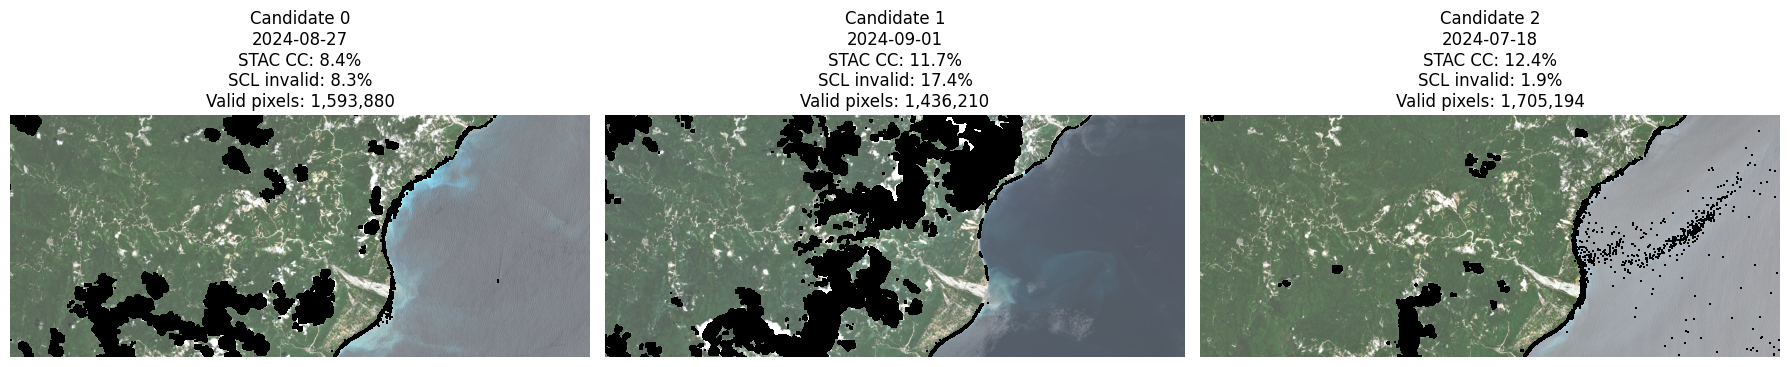

In [10]:
# ============================================================
# Week 12 ARIA v8.0
# Study Area & Data
# Search Top 3 Sentinel-2 Images + SCL Cloud Mask Preview
# ============================================================

# 如果是在 Colab 第一次執行，可以先解除註解安裝套件
# !pip install -q pystac-client planetary-computer stackstac rioxarray rasterio geopandas scikit-learn

import pystac_client
import planetary_computer as pc
import stackstac

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Connect to Microsoft Planetary Computer STAC API
# ------------------------------------------------------------

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

# ------------------------------------------------------------
# 2. Define Xiulin / Taroko study area
# ------------------------------------------------------------

# BBOX format: [west, south, east, north]
TAROKO_BBOX = [121.40, 24.10, 121.80, 24.25]

# ------------------------------------------------------------
# 3. Define classification bands and SCL cloud mask band
# ------------------------------------------------------------

# Reflectance bands for classification
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]

# SCL = Scene Classification Layer, used for cloud / shadow / snow masking
BANDS_ALL = BANDS + ["SCL"]

print("Study area BBOX:")
print(TAROKO_BBOX)

print("\nClassification bands:")
print(BANDS)

print("\nAll bands to load:")
print(BANDS_ALL)

# ------------------------------------------------------------
# 4. Search post-earthquake Sentinel-2 images
# ------------------------------------------------------------
# 這裡不再「找到第一張就停止」
# 而是收集多張候選影像，再挑 STAC cloud cover 最低的前三張

search_configs = [
    ("2024-04-15/2024-04-30", 50, "late April, CC < 50%"),
    ("2024-05-01/2024-05-31", 50, "May, CC < 50%"),
    ("2024-06-01/2024-06-30", 50, "June, CC < 50%"),
    ("2024-07-01/2024-07-31", 50, "July, CC < 50%"),
    ("2024-08-01/2024-08-31", 50, "August, CC < 50%"),
    ("2024-09-01/2024-09-30", 50, "September, CC < 50%"),
    ("2024-10-01/2024-10-31", 50, "October, CC < 50%"),
    ("2024-11-01/2024-11-30", 50, "November, CC < 50%"),
    ("2024-12-01/2024-12-31", 50, "December, CC < 50%"),
]

all_items = []

for dt_range, max_cc, desc in search_configs:
    print(f"\nSearching {desc}...")

    try:
        search = catalog.search(
            collections=["sentinel-2-l2a"],
            bbox=TAROKO_BBOX,
            datetime=dt_range,
            query={"eo:cloud_cover": {"lt": max_cc}},
            max_items=10,
        )

        items = list(search.items())
        print(f"  → Found {len(items)} scenes")

        all_items.extend(items)

    except Exception as e:
        print(f"  → Search failed for this period: {e}")
        print("  → Continue to next period...")

# ------------------------------------------------------------
# 5. Remove duplicated scenes and sort by cloud cover
# ------------------------------------------------------------

unique_items = {}

for item in all_items:
    unique_items[item.id] = item

items_unique = list(unique_items.values())

if len(items_unique) == 0:
    raise ValueError("No Sentinel-2 scenes found. Please relax the search conditions.")

items_sorted = sorted(
    items_unique,
    key=lambda x: x.properties["eo:cloud_cover"]
)

candidate_items = items_sorted[:3]

candidate_info = []

for i, item in enumerate(candidate_items):
    candidate_info.append({
        "Candidate": i,
        "Item_ID": item.id,
        "Date": item.datetime.strftime("%Y-%m-%d"),
        "STAC_Cloud_Cover_percent": round(item.properties["eo:cloud_cover"], 2),
    })

candidate_df = pd.DataFrame(candidate_info)

print("\nTop 3 candidate Sentinel-2 scenes:")
display(candidate_df)

# ------------------------------------------------------------
# 6. Load and preview top 3 candidate images with SCL cloud mask
# ------------------------------------------------------------

# SCL classes to remove:
# 0  = No data
# 1  = Saturated / defective
# 3  = Cloud shadow
# 8  = Cloud medium probability
# 9  = Cloud high probability
# 10 = Thin cirrus
# 11 = Snow / ice

bad_scl_values = [0, 1, 3, 8, 9, 10, 11]

candidate_results = []

for i, item in enumerate(candidate_items):
    print("\n" + "=" * 60)
    print(f"Loading Candidate {i}")
    print(f"Item ID: {item.id}")
    print(f"Date: {item.datetime}")
    print(f"STAC cloud cover: {item.properties['eo:cloud_cover']:.2f}%")

    cube = stackstac.stack(
        [item],
        assets=BANDS_ALL,
        bounds_latlon=TAROKO_BBOX,
        resolution=20,
        epsg=32651
    )

    img = cube.isel(time=0).compute()

    # Separate reflectance bands and SCL
    img_ref = img.sel(band=BANDS)
    img_scl = img.sel(band="SCL")

    # Convert reflectance bands to surface reflectance
    img_sr = img_ref / 10000.0

    # Build SCL cloud / invalid mask
    cloud_mask = np.isin(img_scl.values, bad_scl_values)
    cloud_ratio = np.sum(cloud_mask) / cloud_mask.size

    # Apply cloud mask
    img_sr_masked = img_sr.where(~cloud_mask)

    # Build feature matrix
    n_bands, h, w = img_sr_masked.shape

    X = img_sr_masked.values.reshape(n_bands, -1).T

    valid = ~np.isnan(X).any(axis=1)
    X_valid = X[valid]

    # True color preview: RGB = B04, B03, B02
    rgb = np.stack([
        img_sr_masked.sel(band="B04").values,
        img_sr_masked.sel(band="B03").values,
        img_sr_masked.sel(band="B02").values
    ], axis=-1)

    rgb_vis = np.clip(rgb * 3, 0, 1)

    candidate_results.append({
        "index": i,
        "item": item,
        "img": img,
        "img_sr_masked": img_sr_masked,
        "img_scl": img_scl,
        "cloud_mask": cloud_mask,
        "cloud_ratio": cloud_ratio,
        "X": X,
        "valid": valid,
        "X_valid": X_valid,
        "h": h,
        "w": w,
        "rgb_vis": rgb_vis,
    })

    print(f"Image size: {h} x {w}")
    print(f"SCL cloud / invalid ratio: {cloud_ratio:.3f}")
    print(f"Valid feature matrix: {X_valid.shape}")

# ------------------------------------------------------------
# 7. Display candidate previews
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(candidate_results),
    figsize=(18, 6)
)

if len(candidate_results) == 1:
    axes = [axes]

for ax, result in zip(axes, candidate_results):
    i = result["index"]
    item = result["item"]
    stac_cloud_cover = item.properties["eo:cloud_cover"]
    cloud_ratio = result["cloud_ratio"]
    valid_pixels = result["X_valid"].shape[0]

    ax.imshow(result["rgb_vis"])
    ax.set_title(
        f"Candidate {i}\n"
        f"{item.datetime.strftime('%Y-%m-%d')}\n"
        f"STAC CC: {stac_cloud_cover:.1f}%\n"
        f"SCL invalid: {cloud_ratio:.1%}\n"
        f"Valid pixels: {valid_pixels:,}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()




Selected image for classification:
Candidate: 2
Item ID: S2A_MSIL2A_20240718T022551_R046_T51QUG_20240718T074845
Date: 2024-07-18 02:25:51.024000+00:00
STAC cloud cover: 12.43%
SCL cloud / invalid ratio: 0.019
Image size: 852 x 2041
Feature matrix X: (1738932, 6)
Valid feature matrix X_valid: (1705194, 6)


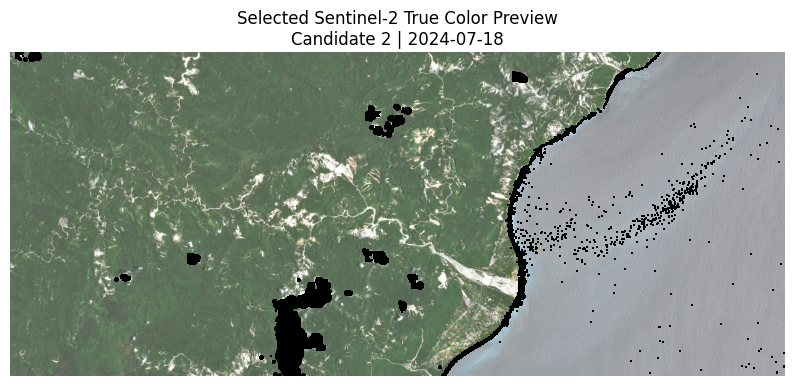

In [11]:
# ------------------------------------------------------------
# 8. Choose one candidate image for the rest of the homework
# ------------------------------------------------------------
# 看完上面的三張圖後，修改 selected_index：
# selected_index = 0, 1, or 2

selected_index = 2

selected = candidate_results[selected_index]

best_item = selected["item"]
img_sr_masked = selected["img_sr_masked"]
img_scl = selected["img_scl"]
cloud_mask = selected["cloud_mask"]

X = selected["X"]
valid = selected["valid"]
X_valid = selected["X_valid"]

h = selected["h"]
w = selected["w"]

print("\n" + "=" * 60)
print("Selected image for classification:")
print(f"Candidate: {selected_index}")
print(f"Item ID: {best_item.id}")
print(f"Date: {best_item.datetime}")
print(f"STAC cloud cover: {best_item.properties['eo:cloud_cover']:.2f}%")
print(f"SCL cloud / invalid ratio: {selected['cloud_ratio']:.3f}")
print(f"Image size: {h} x {w}")
print(f"Feature matrix X: {X.shape}")
print(f"Valid feature matrix X_valid: {X_valid.shape}")

# ------------------------------------------------------------
# 9. Show selected image again
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))
plt.imshow(selected["rgb_vis"])
plt.title(
    f"Selected Sentinel-2 True Color Preview\n"
    f"Candidate {selected_index} | {best_item.datetime.strftime('%Y-%m-%d')}"
)
plt.axis("off")
plt.show()

### Task 1：K-means 非監督式分類

K-means finished.
Labels shape: (1705194,)
Label map shape: (852, 2041)
Present clusters: [0, 1, 2, 3, 4]


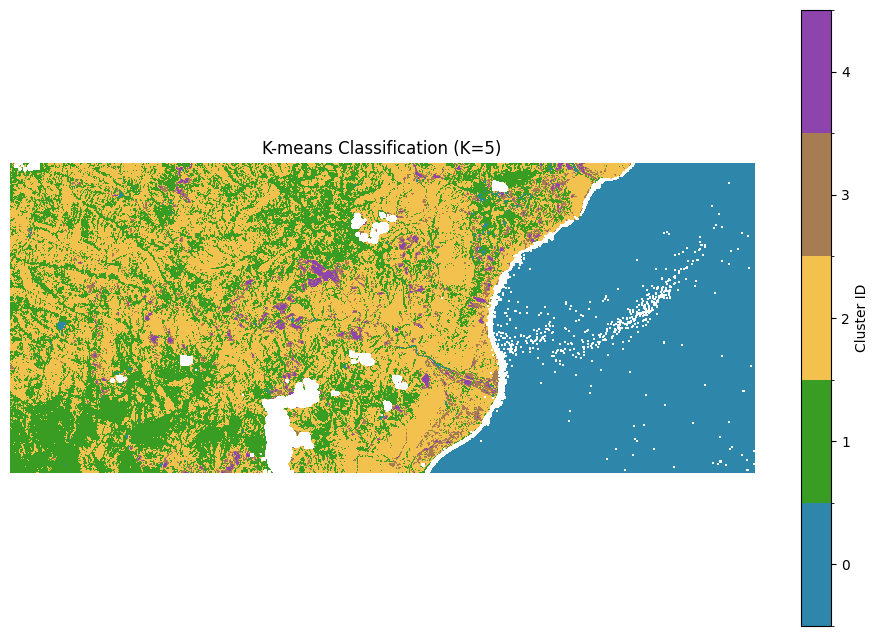

Saved: output\kmeans_classification.png


,Cluster,Pixel_Count,B02_Blue,B03_Green,B04_Red,B08_NIR,B11_SWIR1,B12_SWIR2,Interpreted_Land_Cover
0,0,575571,0.221494,0.216224,0.210871,0.203443,0.208838,0.194461,Water
1,1,475185,0.118367,0.145114,0.124212,0.406645,0.276705,0.179963,Forest
2,2,538906,0.119918,0.155225,0.125433,0.520746,0.313022,0.192373,Dense forest / vegetation
3,3,88284,0.206648,0.232809,0.229926,0.358938,0.355692,0.281729,Built-up / bare surface
4,4,27248,0.347193,0.369754,0.376254,0.403458,0.444067,0.387532,Bright bare land / landslide


In [12]:
# ============================================================
# Task 1: K-means Unsupervised Classification
# Custom discrete colorbar + save to output folder
# ============================================================

from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# 0. Create output folder
# ------------------------------------------------------------

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Run K-means clustering
# ------------------------------------------------------------

n_clusters = 5

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_valid)

print("K-means finished.")
print("Labels shape:", labels.shape)

# ------------------------------------------------------------
# 2. Rebuild 2D label map
# ------------------------------------------------------------

label_map = np.full(h * w, np.nan)
label_map[valid] = labels
label_map = label_map.reshape(h, w)

print("Label map shape:", label_map.shape)

# ------------------------------------------------------------
# 3. Build a custom discrete colormap with ONLY 5 colors
# ------------------------------------------------------------

custom_colors = [
    "#2E86AB",  # Cluster 0 - blue
    "#3A9D23",  # Cluster 1 - green
    "#F2C14E",  # Cluster 2 - yellow
    "#A67C52",  # Cluster 3 - brown
    "#8E44AD",  # Cluster 4 - purple
]

kmeans_cmap = ListedColormap(custom_colors)

bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, kmeans_cmap.N)

present_clusters = sorted([
    int(x) for x in np.unique(label_map[~np.isnan(label_map)])
])

print("Present clusters:", present_clusters)


# ------------------------------------------------------------
# 5. Compute mean spectrum per cluster
# ------------------------------------------------------------

cluster_stats = []

for k in range(n_clusters):
    cluster_pixels = X_valid[labels == k]
    cluster_mean = cluster_pixels.mean(axis=0)
    cluster_count = cluster_pixels.shape[0]

    cluster_stats.append({
        "Cluster": k,
        "Pixel_Count": cluster_count,
        "B02_Blue": cluster_mean[0],
        "B03_Green": cluster_mean[1],
        "B04_Red": cluster_mean[2],
        "B08_NIR": cluster_mean[3],
        "B11_SWIR1": cluster_mean[4],
        "B12_SWIR2": cluster_mean[5],
    })

cluster_df = pd.DataFrame(cluster_stats)


# ------------------------------------------------------------
# 6. Save K-means classification map to output folder
# ------------------------------------------------------------

kmeans_png_path = os.path.join(output_dir, "kmeans_classification.png")

plt.figure(figsize=(12, 8))

im = plt.imshow(
    label_map,
    cmap=kmeans_cmap,
    norm=norm
)

plt.title("K-means Classification (K=5)")

cbar = plt.colorbar(
    im,
    ticks=present_clusters,
    boundaries=bounds
)
cbar.set_label("Cluster ID")

plt.axis("off")
plt.savefig(kmeans_png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {kmeans_png_path}")

# ------------------------------------------------------------
# 7. Add manual land cover interpretation for each K-means cluster
# ------------------------------------------------------------

cluster_label_map = {
    0: "Water",
    1: "Forest",
    2: "Dense forest / vegetation",
    3: "Built-up / bare surface",
    4: "Bright bare land / landslide"
}

cluster_df["Interpreted_Land_Cover"] = cluster_df["Cluster"].map(cluster_label_map)

display(cluster_df)

Q : Brief discussion: which clusters are easy/hard to interpret? Why?

A : 在本次 K-means 分類結果中，Cluster 0 是最容易判釋的類別，因為它主要分布於海域，且 NIR 與 SWIR 反射率相對偏低。這樣的光譜特徵符合水體的特性，因為水體通常會強烈吸收近紅外與短波紅外波段。

Cluster 1 與 Cluster 2 也相對容易判釋為植被相關類別。這兩群都具有較高的 NIR 反射率與較低的紅光反射率，符合森林或濃密植被的典型光譜特徵。不過，Cluster 1 與 Cluster 2 之間的差異較不容易直接解釋。它們可能不是完全不同的土地覆蓋類型，而是受到植被密度、地形陰影、坡向或日照條件影響，導致山區森林被分成不同的光譜群。

Cluster 3 與 Cluster 4 則較難判釋。Cluster 3 具有中高程度的可見光與 SWIR 反射率，因此可能包含建物、道路、裸露土壤、河床砂石或部分崩塌地。Cluster 4 在所有波段反射率都偏高，因此可判釋為高反射裸露地或崩塌裸露面，但也可能包含亮河床、裸岩或其他高反射地表。因此，非植被類別較難被指定為單一土地覆蓋類型，因為 K-means 只是依照光譜相似性分群，並不會理解實際地物意義。

整體而言，水體與植被類別較容易判釋，因為它們具有明顯的光譜特徵；而建物、裸地、河床與崩塌地則較難區分，因為它們在可見光與 SWIR 波段常具有相似的高反射特性。這也顯示 K-means 適合用於探索光譜分群，但仍需要搭配真彩色影像與地理背景進行人工判釋。

### Task 2: Random Forest Supervised Classification

Found KML file: data/label.kml
Number of ROI polygons: 12


,roi_name
0,water01
1,water02
2,forest01
3,forest02
4,cropland01
5,cropland02
6,Bare01
7,Bare02
8,Bare03
9,Built01


ROI class summary:


,class_name,n_polygons
0,Bare,3
1,Builtup,3
2,Cropland,2
3,Forest,2
4,Water,2


Image grid:
Width: 2041, Height: 852
xmin=337360.00, xmax=378160.00
ymin=2665820.00, ymax=2682840.00
Rasterized ROI label map finished.
Training samples:
X_train shape: (18706, 6)
y_train shape: (18706,)
Training sample counts:


,class_id,class_name,n_pixels
0,0,Water,6897
1,1,Forest,9918
2,2,Cropland,219
3,3,Bare,1329
4,4,Builtup,343


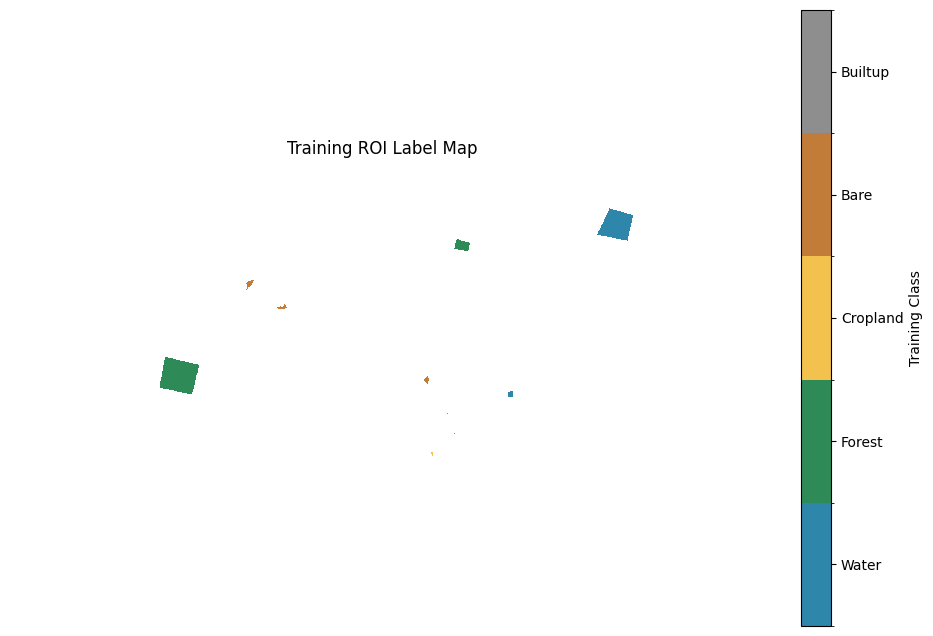

In [13]:
# ============================================================
# Task 2: Load training ROIs from KML and extract training pixels
# Corrected version
# ============================================================

import os
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Polygon
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# 1. KML path
# ------------------------------------------------------------

kml_path = "data/label.kml"

if not os.path.exists(kml_path):
    raise FileNotFoundError(f"Cannot find KML file: {kml_path}")

print(f"Found KML file: {kml_path}")

# ------------------------------------------------------------
# 2. Parse KML polygons
# ------------------------------------------------------------

tree = ET.parse(kml_path)
root = tree.getroot()

ns = {"kml": "http://www.opengis.net/kml/2.2"}

records = []

for pm in root.findall(".//kml:Placemark", ns):
    name_el = pm.find("kml:name", ns)
    coords_el = pm.find(".//kml:coordinates", ns)

    if name_el is None or coords_el is None:
        continue

    roi_name = name_el.text.strip()

    coords = []
    for pt in coords_el.text.strip().split():
        lon, lat, *rest = pt.split(",")
        coords.append((float(lon), float(lat)))

    if len(coords) < 3:
        continue

    geom = Polygon(coords)

    records.append({
        "roi_name": roi_name,
        "geometry": geom
    })

gdf_roi = gpd.GeoDataFrame(records, crs="EPSG:4326")

print("Number of ROI polygons:", len(gdf_roi))
display(gdf_roi[["roi_name"]])

# ------------------------------------------------------------
# 3. Assign class labels from ROI names
# ------------------------------------------------------------

def get_class_name(roi_name):
    name = roi_name.lower()

    if name.startswith("water"):
        return "Water"
    elif name.startswith("forest"):
        return "Forest"
    elif name.startswith("cropland"):
        return "Cropland"
    elif name.startswith("bare"):
        return "Bare"
    elif name.startswith("built"):
        return "Builtup"
    else:
        return None

gdf_roi["class_name"] = gdf_roi["roi_name"].apply(get_class_name)
gdf_roi = gdf_roi.dropna(subset=["class_name"]).copy()

class_names = ["Water", "Forest", "Cropland", "Bare", "Builtup"]

class_id_map = {
    "Water": 0,
    "Forest": 1,
    "Cropland": 2,
    "Bare": 3,
    "Builtup": 4
}

gdf_roi["class_id"] = gdf_roi["class_name"].map(class_id_map)

print("ROI class summary:")
display(gdf_roi.groupby("class_name").size().reset_index(name="n_polygons"))

# ------------------------------------------------------------
# 4. Convert ROI polygons to image CRS
# ------------------------------------------------------------

gdf_roi_utm = gdf_roi.to_crs("EPSG:32651")

# ------------------------------------------------------------
# 5. Build raster transform matching Sentinel-2 image grid
# ------------------------------------------------------------

x_coords = img_sr_masked.x.values
y_coords = img_sr_masked.y.values

xmin = float(np.min(x_coords))
xmax = float(np.max(x_coords))
ymin = float(np.min(y_coords))
ymax = float(np.max(y_coords))

transform = from_bounds(
    xmin, ymin, xmax, ymax,
    w, h
)

print("Image grid:")
print(f"Width: {w}, Height: {h}")
print(f"xmin={xmin:.2f}, xmax={xmax:.2f}")
print(f"ymin={ymin:.2f}, ymax={ymax:.2f}")

# ------------------------------------------------------------
# 6. Rasterize ROI polygons into class map
# ------------------------------------------------------------
# Important fix:
# 這裡每一類都先 rasterize 成 1/0 mask，
# 再把 class_id 寫進 training_label_map。
# 不能直接 rasterize class_id 後再用 class_mask == 1 判斷。

training_label_map = np.full((h, w), fill_value=-1, dtype=np.int16)

for class_name in class_names:
    class_id = class_id_map[class_name]

    gdf_class = gdf_roi_utm[gdf_roi_utm["class_name"] == class_name]

    if len(gdf_class) == 0:
        print(f"Warning: no polygons for {class_name}")
        continue

    shapes = [(geom, 1) for geom in gdf_class.geometry]

    class_mask = rasterize(
        shapes,
        out_shape=(h, w),
        transform=transform,
        fill=0,
        dtype="uint8",
        all_touched=True
    )

    training_label_map[class_mask == 1] = class_id

print("Rasterized ROI label map finished.")

# ------------------------------------------------------------
# 7. Extract training pixels from Sentinel-2 feature matrix
# ------------------------------------------------------------

label_flat = training_label_map.reshape(-1)

train_mask = (label_flat >= 0) & valid

X_train = X[train_mask]
y_train = label_flat[train_mask]

print("Training samples:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# ------------------------------------------------------------
# 8. Training sample count per class
# ------------------------------------------------------------

sample_counts = []

for class_name in class_names:
    class_id = class_id_map[class_name]
    n = np.sum(y_train == class_id)

    sample_counts.append({
        "class_id": class_id,
        "class_name": class_name,
        "n_pixels": int(n)
    })

sample_count_df = pd.DataFrame(sample_counts)

print("Training sample counts:")
display(sample_count_df)

# ------------------------------------------------------------
# 9. Visualize training ROI raster map
# ------------------------------------------------------------

roi_colors = [
    "#2E86AB",  # Water
    "#2E8B57",  # Forest
    "#F2C14E",  # Cropland
    "#C27C3A",  # Bare
    "#8E8E8E",  # Builtup
]

roi_cmap = ListedColormap(roi_colors)
roi_bounds = np.arange(-0.5, len(class_names) + 0.5, 1)
roi_norm = BoundaryNorm(roi_bounds, roi_cmap.N)

roi_vis = training_label_map.astype(float)
roi_vis[roi_vis < 0] = np.nan

plt.figure(figsize=(12, 8))
im = plt.imshow(roi_vis, cmap=roi_cmap, norm=roi_norm)
plt.title("Training ROI Label Map")
cbar = plt.colorbar(im, ticks=list(range(len(class_names))))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Training Class")
plt.axis("off")
plt.show()

Training set: (14964, 6)
Testing set: (3742, 6)
Training accuracy: 1.000
Test accuracy: 0.983
OOB accuracy: 0.982
Class map shape: (852, 2041)


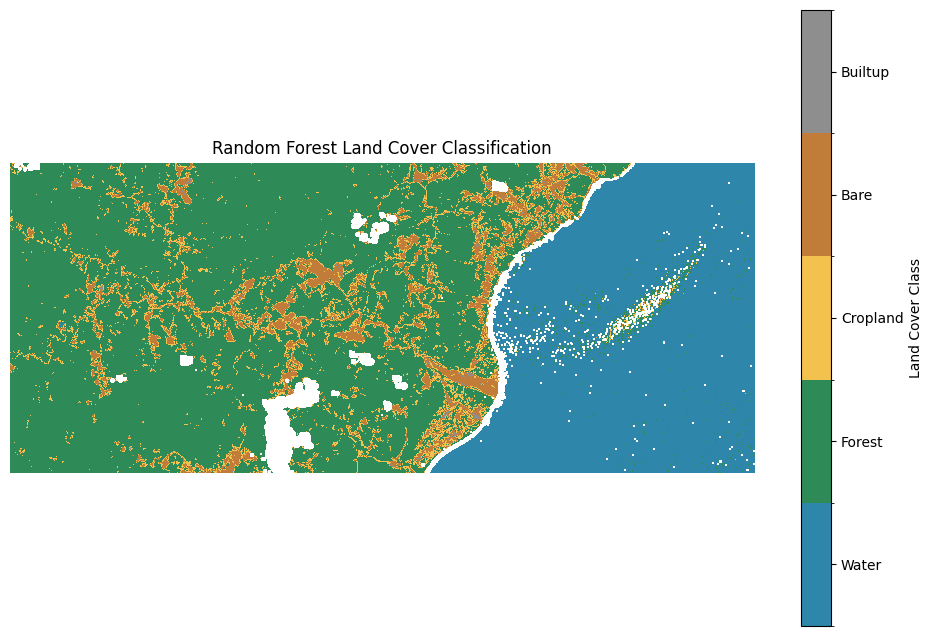

Saved: output\rf_classification.png


,Band,Importance
2,B04,0.250677
0,B02,0.230042
3,B08,0.154378
1,B03,0.153460
4,B11,0.130259
5,B12,0.081183


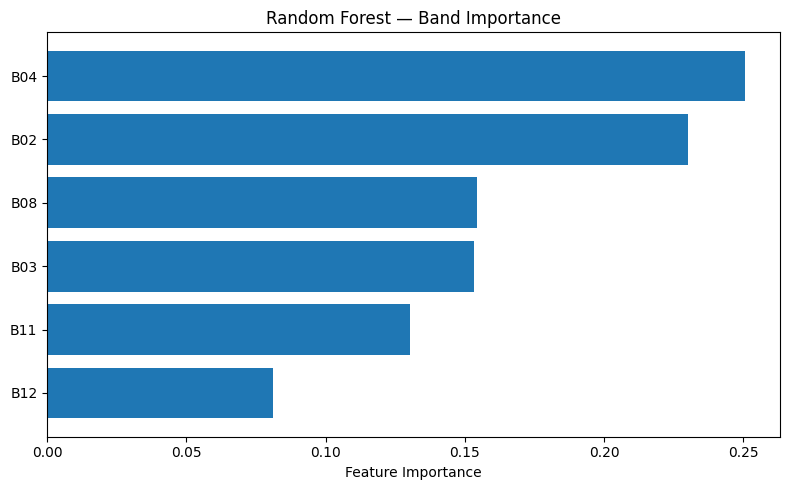

In [17]:
# ============================================================
# Task 2: Random Forest Supervised Classification
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Train/test split
# ------------------------------------------------------------

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_tr.shape)
print("Testing set:", X_te.shape)

# ------------------------------------------------------------
# 2. Train Random Forest
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf.fit(X_tr, y_tr)

print(f"Training accuracy: {rf.score(X_tr, y_tr):.3f}")
print(f"Test accuracy: {rf.score(X_te, y_te):.3f}")
print(f"OOB accuracy: {rf.oob_score_:.3f}")

# ------------------------------------------------------------
# 3. Classify entire image
# ------------------------------------------------------------

y_pred_all = rf.predict(X_valid)

class_map = np.full(h * w, np.nan)
class_map[valid] = y_pred_all
class_map = class_map.reshape(h, w)

print("Class map shape:", class_map.shape)

# ------------------------------------------------------------
# 4. Visualize Random Forest classification map
# ------------------------------------------------------------

class_colors = [
    "#2E86AB",  # Water
    "#2E8B57",  # Forest
    "#F2C14E",  # Cropland
    "#C27C3A",  # Bare
    "#8E8E8E",  # Builtup
]

rf_cmap = ListedColormap(class_colors)
rf_bounds = np.arange(-0.5, len(class_names) + 0.5, 1)
rf_norm = BoundaryNorm(rf_bounds, rf_cmap.N)

# plt.figure(figsize=(12, 8))
# im = plt.imshow(class_map, cmap=rf_cmap, norm=rf_norm)
# plt.title("Random Forest Land Cover Classification")
# cbar = plt.colorbar(im, ticks=list(range(len(class_names))))
# cbar.ax.set_yticklabels(class_names)
# cbar.set_label("Land Cover Class")
# plt.axis("off")
# # plt.show()

# ------------------------------------------------------------
# 5. Save Random Forest classification map
# ------------------------------------------------------------

rf_png_path = os.path.join(output_dir, "rf_classification.png")

plt.figure(figsize=(12, 8))
im = plt.imshow(class_map, cmap=rf_cmap, norm=rf_norm)
plt.title("Random Forest Land Cover Classification")
cbar = plt.colorbar(im, ticks=list(range(len(class_names))))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Land Cover Class")
plt.axis("off")
plt.savefig(rf_png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {rf_png_path}")

# ------------------------------------------------------------
# 6. Feature importance
# ------------------------------------------------------------

band_names = ["B02", "B03", "B04", "B08", "B11", "B12"]

importance = rf.feature_importances_

importance_df = pd.DataFrame({
    "Band": band_names,
    "Importance": importance
}).sort_values("Importance", ascending=True)

display(importance_df.sort_values("Importance", ascending=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Band"], importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest — Band Importance")
plt.tight_layout()
plt.show()

Feature importance 結果中，排名最高的是 B04（Red band），importance = 0.2507。

B04 之所以最重要，是因為紅光波段對於區分 植被與非植被 很有幫助。健康植被通常會吸收較多紅光，因此在 B04 反射率較低；相反地，裸地、建物、道路或河床砂石等非植被地表，在紅光波段的反射率通常較高。因此 Random Forest 可以利用 B04 有效區分 Forest / Cropland 與 Bare / Built-up 等類別。

第二重要的是 B02（Blue band），可能有助於區分水體、亮裸地與建物。B08（NIR） 也很重要，因為近紅外波段能清楚反映植被強弱。整體來看，B04、B02 與 B08 是本次分類中最關鍵的波段。

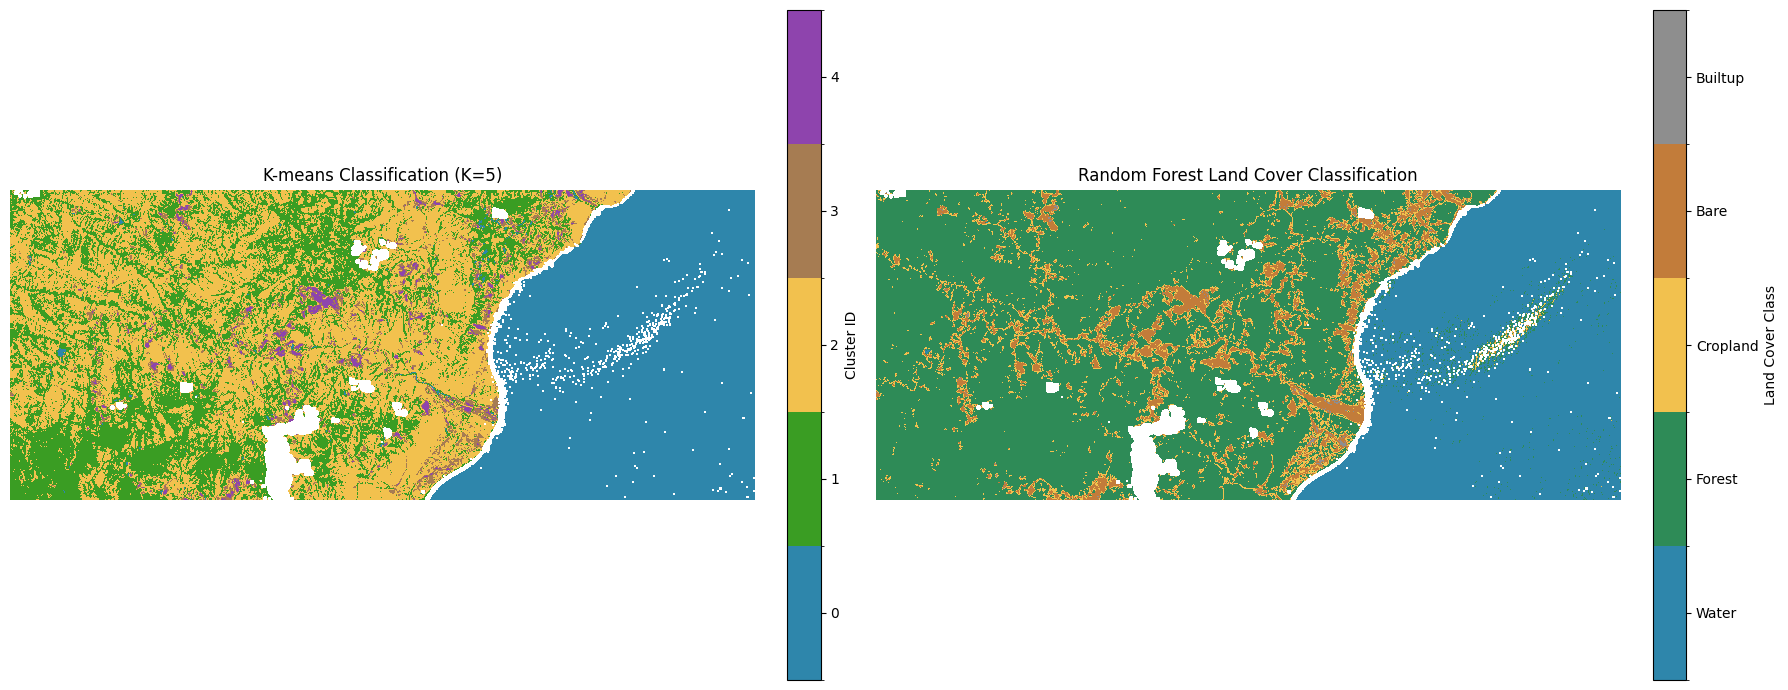

Saved: output\kmeans_vs_rf_comparison.png


In [18]:
# ============================================================
# Task 2: K-means vs Random Forest side-by-side comparison
# ============================================================

import os
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Output path
# ------------------------------------------------------------

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

comparison_png_path = os.path.join(output_dir, "kmeans_vs_rf_comparison.png")

# ------------------------------------------------------------
# 2. Plot side-by-side comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# K-means map
im0 = axes[0].imshow(
    label_map,
    cmap=kmeans_cmap,
    norm=norm
)

axes[0].set_title("K-means Classification (K=5)")
axes[0].axis("off")

cbar0 = fig.colorbar(
    im0,
    ax=axes[0],
    fraction=0.046,
    pad=0.04,
    ticks=present_clusters
)

cbar0.set_label("Cluster ID")

# Random Forest map
im1 = axes[1].imshow(
    class_map,
    cmap=rf_cmap,
    norm=rf_norm
)

axes[1].set_title("Random Forest Land Cover Classification")
axes[1].axis("off")

cbar1 = fig.colorbar(
    im1,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    ticks=list(range(len(class_names)))
)

cbar1.ax.set_yticklabels(class_names)
cbar1.set_label("Land Cover Class")

plt.tight_layout()
plt.savefig(comparison_png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {comparison_png_path}")

相較於 K-means，Random Forest 的分類結果較容易解釋，因為其類別是由訓練樣本所定義。K-means 只依照光譜相似性進行分群，因此部分群集可能混合不同的實際地物，例如裸地、建物、河床與崩塌地。相對地，Random Forest 能將像素分類為 Water、Forest、Cropland、Bare 與 Built-up 等明確土地覆蓋類別。不過，Random Forest 的結果仍高度依賴訓練 ROI 的品質與分布，尤其是 Cropland 與 Built-up 這類樣本較少的類別。

### Task 3 Part A: Internal Accuracy Assessment

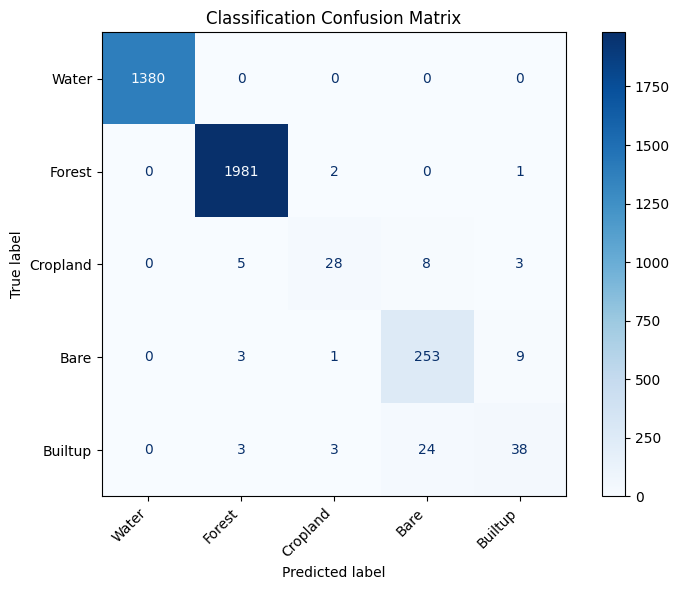

Saved: output\confusion_matrix.png
Classification Report:
              precision    recall  f1-score   support

       Water     1.0000    1.0000    1.0000      1380
      Forest     0.9945    0.9985    0.9965      1984
    Cropland     0.8235    0.6364    0.7179        44
        Bare     0.8877    0.9511    0.9183       266
     Builtup     0.7451    0.5588    0.6387        68

    accuracy                         0.9834      3742
   macro avg     0.8902    0.8290    0.8543      3742
weighted avg     0.9824    0.9834    0.9824      3742



,precision,recall,f1-score,support
Water,1.000000,1.000000,1.000000,1380.000000
Forest,0.994478,0.998488,0.996479,1984.000000
Cropland,0.823529,0.636364,0.717949,44.000000
Bare,0.887719,0.951128,0.918330,266.000000
Builtup,0.745098,0.558824,0.638655,68.000000
accuracy,0.983431,0.983431,0.983431,0.983431
macro avg,0.890165,0.828961,0.854283,3742.000000
weighted avg,0.982384,0.983431,0.982445,3742.000000


OOB Accuracy:  0.9817
Test Accuracy: 0.9834
Macro avg F1:    0.8543
Weighted avg F1: 0.9824
F1 gap:          0.1282
Note: F1 gap > 0.03. Minority classes may be diluted by dominant classes.
Support check:


,class_name,test_support,reliability_note
0,Water,1380,OK
1,Forest,1984,OK
2,Cropland,44,OK
3,Bare,266,OK
4,Builtup,68,OK


In [19]:
# ============================================================
# Task 3 Part A: Internal Accuracy Assessment
# Confusion Matrix + Classification Report + OOB Analysis
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Predict test set
# ------------------------------------------------------------

y_pred_test = rf.predict(X_te)

# ------------------------------------------------------------
# 2. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_te,
    y_pred_test,
    labels=list(range(len(class_names)))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True
)

plt.title("Classification Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

confusion_png_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(confusion_png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {confusion_png_path}")

# ------------------------------------------------------------
# 3. Classification report
# ------------------------------------------------------------

report_text = classification_report(
    y_te,
    y_pred_test,
    target_names=class_names,
    digits=4
)

print("Classification Report:")
print(report_text)

# Also save report as dataframe for easier analysis
report_dict = classification_report(
    y_te,
    y_pred_test,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

# ------------------------------------------------------------
# 4. OOB score and test accuracy
# ------------------------------------------------------------

oob_acc = rf.oob_score_
test_acc = rf.score(X_te, y_te)

print(f"OOB Accuracy:  {oob_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# ------------------------------------------------------------
# 5. Macro vs Weighted F1 analysis
# ------------------------------------------------------------

macro_f1 = report_dict["macro avg"]["f1-score"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]
f1_gap = weighted_f1 - macro_f1

print(f"Macro avg F1:    {macro_f1:.4f}")
print(f"Weighted avg F1: {weighted_f1:.4f}")
print(f"F1 gap:          {f1_gap:.4f}")

if f1_gap > 0.03:
    print("Note: F1 gap > 0.03. Minority classes may be diluted by dominant classes.")
else:
    print("Note: F1 gap <= 0.03. Macro and weighted performance are relatively consistent.")

# ------------------------------------------------------------
# 6. Support check per class
# ------------------------------------------------------------

support_info = []

for class_name in class_names:
    support = report_dict[class_name]["support"]
    support_info.append({
        "class_name": class_name,
        "test_support": int(support),
        "reliability_note": "Low support (<30), interpret carefully" if support < 30 else "OK"
    })

support_df = pd.DataFrame(support_info)

print("Support check:")
display(support_df)

### Task 3 Part B: Independent Validation with SWCB Landslide Inventory

Found SWCB KML file: data/20240802新生崩塌地.kml
Total SWCB landslide polygons loaded: 1354
SWCB landslide polygons in study area: 212
Image grid for rasterization:
Width: 2041, Height: 852
xmin=337360.00, xmax=378160.00
ymin=2665820.00, ymax=2682840.00
SWCB landslide pixels: 4011
RF Bare/Landslide pixels: 100542
Bare class ID: 3
SWCB overlap metrics:


,Metric,Value
0,SWCB landslide pixels,4011.0000
1,RF Bare/Landslide pixels,100542.0000
2,Intersection pixels,320.0000
3,Union pixels,104233.0000
4,Recall,0.0798
5,Precision,0.0032
6,IoU,0.0031


Saved: output\swcb_overlap_metrics.csv


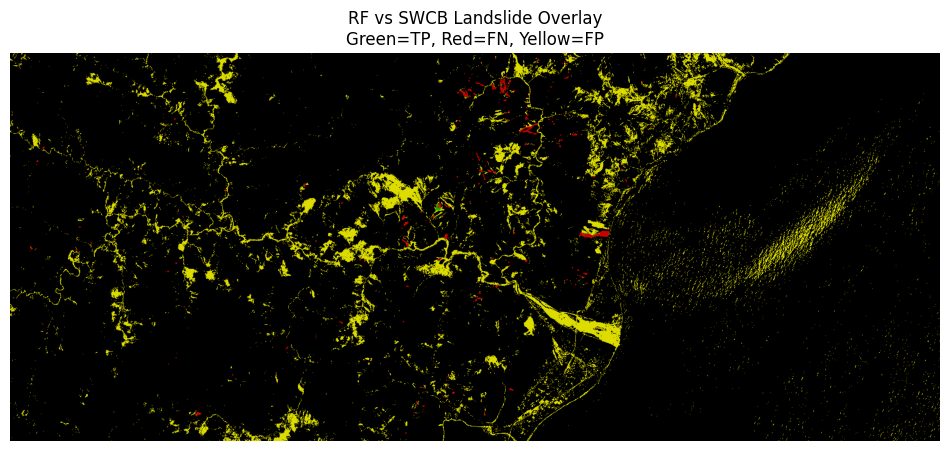

Saved: output\swcb_overlay.png


In [20]:
# ============================================================
# Task 3 Part B: Independent Validation with SWCB Landslide Inventory
# ============================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from shapely.geometry import Polygon, box
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# ------------------------------------------------------------
# 0. Paths
# ------------------------------------------------------------

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

swcb_kml_path = "data/20240802新生崩塌地.kml"

if not os.path.exists(swcb_kml_path):
    raise FileNotFoundError(f"Cannot find SWCB KML file: {swcb_kml_path}")

print(f"Found SWCB KML file: {swcb_kml_path}")

# ------------------------------------------------------------
# 1. Parse SWCB KML polygons
# ------------------------------------------------------------

tree = ET.parse(swcb_kml_path)
root = tree.getroot()

ns = {"kml": "http://www.opengis.net/kml/2.2"}

polygons = []

for pm in root.findall(".//kml:Placemark", ns):
    coords_elements = pm.findall(".//kml:coordinates", ns)

    for coords_el in coords_elements:
        if coords_el is None or coords_el.text is None:
            continue

        coords = []

        for pt in coords_el.text.strip().split():
            lon, lat, *rest = pt.split(",")
            coords.append((float(lon), float(lat)))

        if len(coords) >= 3:
            try:
                poly = Polygon(coords)
                if poly.is_valid and not poly.is_empty:
                    polygons.append(poly)
            except Exception:
                pass

gdf_swcb = gpd.GeoDataFrame(
    geometry=polygons,
    crs="EPSG:4326"
)

print(f"Total SWCB landslide polygons loaded: {len(gdf_swcb)}")

# ------------------------------------------------------------
# 2. Clip SWCB polygons to Taroko study area
# ------------------------------------------------------------

study_box = box(*TAROKO_BBOX)

gdf_clipped = gdf_swcb[gdf_swcb.intersects(study_box)].copy()

print(f"SWCB landslide polygons in study area: {len(gdf_clipped)}")

if len(gdf_clipped) == 0:
    raise ValueError("No SWCB landslide polygons intersect the study area. Please check KML or BBOX.")

# ------------------------------------------------------------
# 3. Convert SWCB polygons to image CRS
# ------------------------------------------------------------
# Your Sentinel-2 image was loaded with epsg=32651.
# Therefore, rasterization should also be done in EPSG:32651.

gdf_clipped_utm = gdf_clipped.to_crs("EPSG:32651")

# ------------------------------------------------------------
# 4. Build transform matching Sentinel-2 grid
# ------------------------------------------------------------

x_coords = img_sr_masked.x.values
y_coords = img_sr_masked.y.values

xmin = float(np.min(x_coords))
xmax = float(np.max(x_coords))
ymin = float(np.min(y_coords))
ymax = float(np.max(y_coords))

transform = from_bounds(
    xmin,
    ymin,
    xmax,
    ymax,
    w,
    h
)

print("Image grid for rasterization:")
print(f"Width: {w}, Height: {h}")
print(f"xmin={xmin:.2f}, xmax={xmax:.2f}")
print(f"ymin={ymin:.2f}, ymax={ymax:.2f}")

# ------------------------------------------------------------
# 5. Rasterize SWCB landslide polygons
# ------------------------------------------------------------

swcb_mask = rasterize(
    [(geom, 1) for geom in gdf_clipped_utm.geometry],
    out_shape=(h, w),
    transform=transform,
    fill=0,
    dtype="uint8",
    all_touched=True
)

print(f"SWCB landslide pixels: {swcb_mask.sum()}")

# ------------------------------------------------------------
# 6. Extract RF Bare / Landslide class
# ------------------------------------------------------------
# According to your class_names:
# ["Water", "Forest", "Cropland", "Bare", "Builtup"]
# Bare class_id = 3

bare_class_id = class_names.index("Bare")

rf_landslide = (class_map == bare_class_id).astype(np.uint8)

print(f"RF Bare/Landslide pixels: {rf_landslide.sum()}")
print(f"Bare class ID: {bare_class_id}")

# ------------------------------------------------------------
# 7. Compute spatial overlap metrics
# ------------------------------------------------------------

intersection = np.sum((rf_landslide == 1) & (swcb_mask == 1))
union = np.sum((rf_landslide == 1) | (swcb_mask == 1))

swcb_total = np.sum(swcb_mask == 1)
rf_total = np.sum(rf_landslide == 1)

recall = intersection / swcb_total if swcb_total > 0 else 0
precision = intersection / rf_total if rf_total > 0 else 0
iou = intersection / union if union > 0 else 0

metrics_df = pd.DataFrame({
    "Metric": [
        "SWCB landslide pixels",
        "RF Bare/Landslide pixels",
        "Intersection pixels",
        "Union pixels",
        "Recall",
        "Precision",
        "IoU"
    ],
    "Value": [
        int(swcb_total),
        int(rf_total),
        int(intersection),
        int(union),
        round(recall, 4),
        round(precision, 4),
        round(iou, 4)
    ]
})

print("SWCB overlap metrics:")
display(metrics_df)

# ------------------------------------------------------------
# 8. Save metrics table
# ------------------------------------------------------------

metrics_csv_path = os.path.join(output_dir, "swcb_overlap_metrics.csv")
metrics_df.to_csv(metrics_csv_path, index=False, encoding="utf-8-sig")

print(f"Saved: {metrics_csv_path}")

# ------------------------------------------------------------
# 9. Create TP / FN / FP overlay
# ------------------------------------------------------------
# TP = RF landslide and SWCB landslide
# FN = SWCB landslide but RF did not detect
# FP = RF landslide but not in SWCB

overlay = np.zeros((h, w, 3), dtype=np.uint8)

# True Positive: green
overlay[(rf_landslide == 1) & (swcb_mask == 1)] = [0, 200, 0]

# False Negative: red
overlay[(rf_landslide == 0) & (swcb_mask == 1)] = [200, 0, 0]

# False Positive: yellow
overlay[(rf_landslide == 1) & (swcb_mask == 0)] = [220, 220, 0]

# ------------------------------------------------------------
# 10. Visualize and save overlay
# ------------------------------------------------------------

swcb_overlay_path = os.path.join(output_dir, "swcb_overlay.png")

plt.figure(figsize=(12, 8))
plt.imshow(overlay)
plt.title("RF vs SWCB Landslide Overlay\nGreen=TP, Red=FN, Yellow=FP")
plt.axis("off")
plt.savefig(swcb_overlay_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {swcb_overlay_path}")

   ### Discussion questions（必答）：
   - Why is perfect overlap (IoU = 1.0) unlikely? Consider: temporal gap（影像日期 vs SWCB 判釋日期）, spatial resolution (Sentinel-2 20m vs high-res imagery), class definition differences
   - 完美重疊幾乎不可能發生，因為 RF 分類圖與 SWCB 崩塌地資料使用的資料來源、空間解析度、時間與類別定義皆不同。RF 分類使用 20 m Sentinel-2 影像，而 SWCB 崩塌地資料是由高解析度影像判釋而來，因此較小或狹長的崩塌地可能無法在 Sentinel-2 影像中清楚呈現。此外，Sentinel-2 影像日期與 SWCB 判釋日期不同，期間可能受到植生恢復、侵蝕變化、雲影或地形陰影影響。最重要的是，RF 的 Bare/Landslide 類別代表廣義的非植被裸露地表，而 SWCB 僅標示官方判釋的新生崩塌地。
   - Where are the FN (missed) landslides concentrated? What might explain this?
   - FN 像素主要對應 overlay 圖中的紅色區域，代表 SWCB 判釋為崩塌地，但 RF 未分類為 Bare 的位置。這些漏判區可能集中於山坡、狹長溝谷或較小型崩塌地。可能原因包括 Sentinel-2 20 m 解析度造成混合像素、崩塌地面積過小、部分植被覆蓋、地形陰影，以及與森林或其他地物類別的光譜混淆。
   - How does this external validation compare to your internal test accuracy?
   - 內部測試精度為 0.9834，表現非常高；但外部 SWCB 驗證的 IoU 僅為 0.0031，顯示兩者結果差異很大。這說明以訓練樣本切分得到的內部精度可能高估模型在真實獨立資料上的表現，尤其訓練與測試樣本都來自人工選取的 ROI。SWCB 驗證更嚴格，因為它使用獨立官方崩塌地資料檢查 RF 的 Bare/Landslide 類別是否真正對應到災後崩塌地。因此，本分類器對一般土地覆蓋分類表現良好，但若要作為正式崩塌地偵測工具，仍需要更精細的崩塌訓練樣本與後續修正。

### Task 4 : Area statistics per class

In [21]:
# ============================================================
# Task 4 Step 1: Area statistics per class
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Calculate area statistics
# ------------------------------------------------------------

pixel_area_m2 = 20 * 20  # Sentinel-2 20 m resolution
pixel_area_ha = pixel_area_m2 / 10000  # 1 ha = 10,000 m2

valid_class_pixels = np.sum(~np.isnan(class_map))

class_stats = {}

for i, name in enumerate(class_names):
    n_pixels = np.sum(class_map == i)
    area_ha = n_pixels * pixel_area_ha
    percentage = n_pixels / valid_class_pixels * 100

    class_stats[name] = {
        "pixels": int(n_pixels),
        "area_ha": round(area_ha, 1),
        "percentage": round(percentage, 1)
    }

stats_df = pd.DataFrame(class_stats).T

print("Area statistics per class:")
display(stats_df)

# ------------------------------------------------------------
# 2. Save area statistics table
# ------------------------------------------------------------

stats_csv_path = os.path.join(output_dir, "class_area_stats.csv")
stats_df.to_csv(stats_csv_path, encoding="utf-8-sig")

print(f"Saved: {stats_csv_path}")

Area statistics per class:


,pixels,area_ha,percentage
Water,545692.0,21827.7,32.0
Forest,986192.0,39447.7,57.8
Cropland,36037.0,1441.5,2.1
Bare,100542.0,4021.7,5.9
Builtup,36731.0,1469.2,2.2


Saved: output\class_area_stats.csv


### Task 4 : LLM-generated classification report

In [24]:
# ============================================================
# Gemini API setup
# ============================================================

import os
import google.generativeai as genai
from dotenv import load_dotenv

# ------------------------------------------------------------
# 1. Load API key from .env
# ------------------------------------------------------------

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

if api_key is None:
    raise ValueError("GEMINI_API_KEY not found. Please check your .env file.")

# ------------------------------------------------------------
# 2. Configure Gemini
# ------------------------------------------------------------

genai.configure(api_key=api_key)

model = genai.GenerativeModel("gemini-2.5-flash-lite")

print("Gemini API key loaded successfully.")

# ============================================================
# Task 4 Step 2: LLM-generated classification report
# ============================================================

overall_accuracy = rf.score(X_te, y_te)
swcb_iou = iou

prompt = f"""
你是花蓮縣災害應變中心的 GIS 分析師。根據以下災後土地覆蓋分類結果，
撰寫一份「災後土地覆蓋分析報告」（中文，300-500 字）。

研究區：秀林鄉 / 太魯閣周邊（含蘇花公路沿線及近海區域）
災害事件：2024 年 4 月 3 日花蓮地震（M7.4）
影像日期：{best_item.datetime.strftime('%Y-%m-%d')}
分類方法：Random Forest（6 波段 Sentinel-2，5 類別）
Overall accuracy: {overall_accuracy:.1%}
OOB accuracy: {rf.oob_score_:.1%}
SWCB landslide IoU: {swcb_iou:.4f}

各類別面積：
{stats_df.to_string()}

SWCB 外部驗證結果：
Recall: {recall:.4f}
Precision: {precision:.4f}
IoU: {iou:.4f}

報告需包含：
1. 災後土地覆蓋概況
2. 崩塌/裸地面積估計及其空間分布
3. 與 SWCB 官方判釋的比對結果 + 不確定性說明
4. 建議：這張分類圖可以如何支援後續的避難所評估或路網分析？

請注意：
- 不要編造表格中沒有的數字
- 所有面積數字必須與上方表格一致
- 請說明 RF Bare 類別與 SWCB 新生崩塌地定義不同，因此 IoU 偏低是合理的
"""

response = model.generate_content(prompt)

llm_report = response.text

print("LLM-generated report:")
print(llm_report)

report_path = os.path.join(output_dir, "llm_classification_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write(llm_report)

print(f"Saved: {report_path}")


Gemini API key loaded successfully.
LLM-generated report:
**花蓮縣秀林鄉太魯閣周邊區域 2024 年 4 月 3 日花蓮地震災後土地覆蓋分析報告**

**報告日期：** 2024 年 7 月 25 日
**分析師：** [您的姓名]，花蓮縣災害應變中心 GIS 分析師
**研究區：** 秀林鄉 / 太魯閣周邊（含蘇花公路沿線及近海區域）
**災後影像日期：** 2024-07-18
**災害事件：** 2024 年 4 月 3 日花蓮地震 (M7.4)

**1. 災後土地覆蓋概況**

本次分析採用 Random Forest 分類模型，基於 6 波段 Sentinel-2 影像，對秀林鄉太魯閣周邊區域進行災後土地覆蓋分類。整體分類結果的 Overall accuracy 達 98.3%，OOB accuracy 亦達 98.2%，顯示分類精度相當高。

分析結果顯示，研究區災後土地覆蓋面積比例最高的是**森林 (Forest)**，佔總面積的 57.8% (39447.7 公頃)，其次為**水域 (Water)**，佔 32.0% (21827.7 公頃)。**裸地 (Bare)** 佔 5.9% (4021.7 公頃)，**農地 (Cropland)** 佔 2.1% (1441.5 公頃)，**建蔽區 (Builtup)** 佔 2.2% (1469.2 公頃)。

**2. 崩塌/裸地面積估計及其空間分布**

本次分類結果中，**裸地 (Bare)** 類別的面積為 4021.7 公頃。此類別主要反映了地震造成的地面裸露，可能包含因邊坡崩塌、地表開裂或土壤剝離而形成的區域。其空間分布預期將集中在太魯閣國家公園內部的山區、蘇花公路沿線的陡峭邊坡，以及地震較為劇烈的斷層帶附近。

**3. 與 SWCB 官方判釋的比對結果 + 不確定性說明**

將本次 RF 分類結果中的崩塌/裸地類別與水土保持局 (SWCB) 官方判釋的新生崩塌地進行比對，發現 SWCB 崩塌地的 IoU (Intersection over Union) 僅為 0.0031，Recall 為 0.0798，Precision 僅為 0.0032。

此低 IoU 和 Precision 是可以理解的。SWCB 官方判釋的「新

**LLM output evaluation：**

LLM 產生的報告大致能正確整理土地覆蓋分類結果，其中 Forest、Water、Bare、Cropland 與 Built-up 的面積數字皆與 area statistics table 一致，因此沒有發現明顯的面積數字幻覺。報告也正確引用了 overall accuracy、OOB accuracy，以及 SWCB 外部驗證中的 Recall、Precision 和 IoU 數值。

不過，報告中的不確定性描述仍需要修正。報告提到 RF 的 Bare 類別「必然包含」SWCB 定義的新生崩塌地，這個說法過於絕對，且與驗證結果不完全一致。實際上，兩者交集只有 320 pixels，Recall 僅為 0.0798，代表大多數 SWCB 崩塌地並沒有被 RF 模型分類為 Bare。較合理的說法應是：RF 的 Bare 類別可能涵蓋部分 SWCB 新生崩塌地，但兩者的實際空間重疊有限。

此外，我也會修正報告最後提到高 overall accuracy「保證」可靠性的說法。雖然測試精度很高，但 macro F1-score 明顯低於 weighted F1-score，且 SWCB IoU 非常低，表示模型對 Water 和 Forest 等主要類別表現良好，但對少數類別與崩塌相關判釋仍存在不確定性。因此，我會補充說明 Bare 類別應被視為廣義的非植被裸露地表，可能包含河床、道路、裸露土壤、裸岩與部分崩塌裸露面，而不能直接等同於專門的崩塌偵測結果。